In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set plotting styles
plt.style.use('ggplot')
sns.set(style="whitegrid")
# Load the dataset
df = pd.read_csv('EV_Dataset.csv')

In [3]:
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [4]:
df.Date

0         1/1/2014
1         1/1/2014
2         1/1/2014
3         1/1/2014
4         1/1/2014
           ...    
96840    12/1/2023
96841    12/1/2023
96842    12/1/2023
96843    12/1/2023
96844    12/1/2023
Name: Date, Length: 96845, dtype: object

In [5]:
# 1. Exploratory Data Analysis (EDA)
print("Dataset Shape:", df.shape)
# Convert Year to appropriate type if needed
if df['Year'].dtype == 'object':
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

Dataset Shape: (96845, 8)


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Year                 float64
Month_Name            object
Date                  object
State                 object
Vehicle_Class         object
Vehicle_Category      object
Vehicle_Type          object
EV_Sales_Quantity    float64
dtype: object


In [7]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64


In [8]:
# Basic statistics of EV sales
print("\nEV Sales Statistics:")
print(df['EV_Sales_Quantity'].describe())


EV Sales Statistics:
count    96845.000000
mean        37.108896
std        431.566675
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      20584.000000
Name: EV_Sales_Quantity, dtype: float64


In [9]:
df.Vehicle_Category.unique()

array(['Others', 'Bus', '2-Wheelers', '4-Wheelers', '3-Wheelers'],
      dtype=object)

In [10]:
df.groupby('State')['EV_Sales_Quantity'].sum()

State
Andaman & Nicobar Island       202.0
Andhra Pradesh               77356.0
Arunachal Pradesh               40.0
Assam                       151917.0
Bihar                       213465.0
Chandigarh                   11453.0
Chhattisgarh                 75275.0
DNH and DD                     431.0
Delhi                       268538.0
Goa                          17382.0
Gujarat                     176713.0
Haryana                      85250.0
Himachal Pradesh              2886.0
Jammu and Kashmir            16840.0
Jharkhand                    47871.0
Karnataka                   315498.0
Kerala                      133246.0
Ladakh                          88.0
Madhya Pradesh              133182.0
Maharashtra                 401535.0
Manipur                       1284.0
Meghalaya                      208.0
Mizoram                        235.0
Nagaland                        52.0
Odisha                       86823.0
Puducherry                    5139.0
Punjab                       492

In [11]:
# 2. Feature Engineering

# Create date column for time-based analysis
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year_Month'] = df['Date'].dt.to_period('M')

# Create aggregated features
# Sales by vehicle category
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].agg(['sum', 'mean', 'count']).reset_index()
category_sales.columns = ['Vehicle_Category', 'Total_Sales', 'Average_Sales', 'Count']
category_sales['Market_Share'] = category_sales['Total_Sales'] / category_sales['Total_Sales'].sum() * 100
category_sales = category_sales.sort_values('Total_Sales', ascending=False)

In [12]:
print("\nSales by Vehicle Category:")
print(category_sales)


Sales by Vehicle Category:
  Vehicle_Category  Total_Sales  Average_Sales  Count  Market_Share
0       2-Wheelers    1808105.0     137.802378  13121     50.311633
1       3-Wheelers    1620310.0     141.006875  11491     45.086122
2       4-Wheelers     149775.0      17.233345   8691      4.167581
4           Others       8612.0       0.158242  54423      0.239634
3              Bus       7009.0       0.768615   9119      0.195030


In [13]:
# Sales by vehicle type
type_sales = df.groupby('Vehicle_Type')['EV_Sales_Quantity'].agg(['sum', 'mean', 'count']).reset_index()
type_sales.columns = ['Vehicle_Type', 'Total_Sales', 'Average_Sales', 'Count']
type_sales['Market_Share'] = type_sales['Total_Sales'] / type_sales['Total_Sales'].sum() * 100
type_sales = type_sales.sort_values('Total_Sales', ascending=False)

print("\nSales by Vehicle Type:")
print(type_sales)



Sales by Vehicle Type:
          Vehicle_Type  Total_Sales  Average_Sales  Count  Market_Share
0          2W_Personal    1796340.0     153.533333  11700     49.984265
6   3W_Shared_LowSpeed    1408127.0     721.746284   1951     39.181999
7          4W_Personal     130676.0      31.786913   4111      3.636140
3    3W_Goods_LowSpeed      90656.0      59.760053   1517      2.522559
5            3W_Shared      76132.0      20.108822   3786      2.118420
2             3W_Goods      44974.0      14.019327   3208      1.251429
8            4W_Shared      19099.0       4.170087   4580      0.531441
1            2W_Shared      11765.0       8.279381   1421      0.327368
11              Others       8612.0       0.158242  54423      0.239634
9                  Bus       7009.0       0.997580   7026      0.195030
4          3W_Personal        421.0       0.409135   1029      0.011715
10     Institution Bus          0.0       0.000000   2093      0.000000


In [14]:
# Sales by vehicle class
class_sales = df.groupby('Vehicle_Class')['EV_Sales_Quantity'].agg(['sum', 'mean', 'count']).reset_index()
class_sales.columns = ['Vehicle_Class', 'Total_Sales', 'Average_Sales', 'Count']
class_sales['Market_Share'] = class_sales['Total_Sales'] / class_sales['Total_Sales'].sum() * 100
class_sales = class_sales.sort_values('Total_Sales', ascending=False)

print("\nSales by Vehicle Class:")
print(class_sales)


Sales by Vehicle Class:
                Vehicle_Class  Total_Sales  Average_Sales  Count  Market_Share
31            M-CYCLE/SCOOTER    1697373.0     413.892465   4101     47.230447
18              E-RICKSHAW(P)    1408127.0     721.746284   1951     39.181999
40                  MOTOR CAR     130676.0      31.786913   4111      3.636140
17   E-RICKSHAW WITH CART (G)      90656.0      59.760053   1517      2.522559
59  THREE WHEELER (PASSENGER)      76132.0      20.108822   3786      2.118420
..                        ...          ...            ...    ...           ...
48               POWER TILLER          0.0       0.000000     81      0.000000
28                    HEARSES          0.0       0.000000    618      0.000000
29                LIBRARY VAN          0.0       0.000000     93      0.000000
34             MOBILE CANTEEN          0.0       0.000000    133      0.000000
36            MOBILE WORKSHOP          0.0       0.000000    309      0.000000

[73 rows x 5 columns]


In [15]:
# Calculate yearly growth for each category
yearly_category_sales = df.groupby(['Year', 'Vehicle_Category'])['EV_Sales_Quantity'].sum().reset_index()
pivot_yearly = yearly_category_sales.pivot(index='Vehicle_Category', columns='Year', values='EV_Sales_Quantity').fillna(0)

# Calculate growth rates (most recent year compared to earliest year)
years = sorted(df['Year'].unique())
if len(years) > 1:
    earliest_year = years[0]
    latest_year = years[-1]
    
    # Avoid division by zero by adding a small constant
    pivot_yearly['Growth_Rate'] = (pivot_yearly[latest_year] - pivot_yearly[earliest_year]) / (pivot_yearly[earliest_year] + 1) * 100
    
    # Merge growth rate back to category_sales
    category_sales = category_sales.merge(pivot_yearly['Growth_Rate'].reset_index(), on='Vehicle_Category', how='left')
    
    print("\nCategory Growth Rates (%):")
    print(category_sales[['Vehicle_Category', 'Growth_Rate']].sort_values('Growth_Rate', ascending=False))


Category Growth Rates (%):
  Vehicle_Category    Growth_Rate
1       3-Wheelers  407000.000000
4              Bus   12575.000000
0       2-Wheelers    4741.904762
2       4-Wheelers    1496.993988
3           Others     120.895522


In [16]:
# 3. Geographic Analysis (State-wise)
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().reset_index()
state_sales = state_sales.sort_values('EV_Sales_Quantity', ascending=False)
top_states = state_sales.head(10)

print("\nTop 10 States by EV Sales:")
print(top_states)


Top 10 States by EV Sales:
            State  EV_Sales_Quantity
31  Uttar Pradesh           732074.0
19    Maharashtra           401535.0
15      Karnataka           315498.0
8           Delhi           268538.0
27      Rajasthan           228573.0
4           Bihar           213465.0
29     Tamil Nadu           206902.0
10        Gujarat           176713.0
3           Assam           151917.0
16         Kerala           133246.0


In [17]:

# Combined analysis for market segmentation
category_state_sales = df.groupby(['Vehicle_Category', 'State'])['EV_Sales_Quantity'].sum().reset_index()
category_state_sales = category_state_sales.sort_values('EV_Sales_Quantity', ascending=False)
top_category_state = category_state_sales.head(15)

print("\nTop 15 Category-State Combinations:")
print(top_category_state)


Top 15 Category-State Combinations:
   Vehicle_Category           State  EV_Sales_Quantity
64       3-Wheelers   Uttar Pradesh           641906.0
19       2-Wheelers     Maharashtra           342236.0
15       2-Wheelers       Karnataka           278671.0
38       3-Wheelers           Bihar           184394.0
29       2-Wheelers      Tamil Nadu           181735.0
42       3-Wheelers           Delhi           161868.0
10       2-Wheelers         Gujarat           157871.0
37       3-Wheelers           Assam           145575.0
27       2-Wheelers       Rajasthan           137724.0
16       2-Wheelers          Kerala           108118.0
8        2-Wheelers           Delhi            85358.0
31       2-Wheelers   Uttar Pradesh            83769.0
61       3-Wheelers       Rajasthan            83485.0
24       2-Wheelers          Odisha            75449.0
18       2-Wheelers  Madhya Pradesh            70420.0


In [18]:

# 4. Temporal Analysis
monthly_sales = df.groupby('Month_Name')['EV_Sales_Quantity'].sum().reset_index()
# Create a proper order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['Month_Order'] = monthly_sales['Month_Name'].map({month: i for i, month in enumerate(month_order)})
monthly_sales = monthly_sales.sort_values('Month_Order')

print("\nMonthly Sales Pattern:")
print(monthly_sales[['Month_Name', 'EV_Sales_Quantity']])


Monthly Sales Pattern:
   Month_Name  EV_Sales_Quantity
0         apr           232194.0
1         aug           294022.0
2         dec           364558.0
3         feb           228739.0
4         jan           360703.0
5         jul           270473.0
6         jun           229754.0
7         mar           299888.0
8         may           262747.0
9         nov           382217.0
10        oct           355083.0
11        sep           313433.0


In [19]:
#5. Market Segmentation using K-means clustering
if 'Growth_Rate' in category_sales.columns:
    segment_data = category_sales[['Total_Sales', 'Average_Sales', 'Market_Share', 'Growth_Rate']]
else:
    segment_data = category_sales[['Total_Sales', 'Average_Sales', 'Market_Share']]
# Handle missing values
segment_data = segment_data.fillna(0)
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_data)
# Determine optimal number of clusters using the elbow method
inertia = []
k_range = range(1, min(10, len(segment_data) + 1))
for k in k_range:
    if k < len(scaled_data):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(scaled_data)
        inertia.append(kmeans.inertia_)
# Apply K-means clustering (choosing k=3 or optimal k from elbow method)
optimal_k = 3  # Default, can be adjusted based on elbow method
if len(inertia) > 2:
    # Simple method to find elbow point
    diffs = np.diff(inertia)
    optimal_k = np.argmax(np.diff(diffs)) + 2  # +2 because of double diff and 0-index

kmeans = KMeans(n_clusters=min(optimal_k, len(scaled_data)-1), random_state=42)
category_sales['Cluster'] = kmeans.fit_predict(scaled_data)

print("\nMarket Segmentation Results:")
print(category_sales[['Vehicle_Category', 'Total_Sales', 'Market_Share', 'Cluster']].sort_values('Cluster'))


Market Segmentation Results:
  Vehicle_Category  Total_Sales  Market_Share  Cluster
0       2-Wheelers    1808105.0     50.311633        0
1       3-Wheelers    1620310.0     45.086122        0
2       4-Wheelers     149775.0      4.167581        1
3           Others       8612.0      0.239634        1
4              Bus       7009.0      0.195030        1


# 6. Visualizations

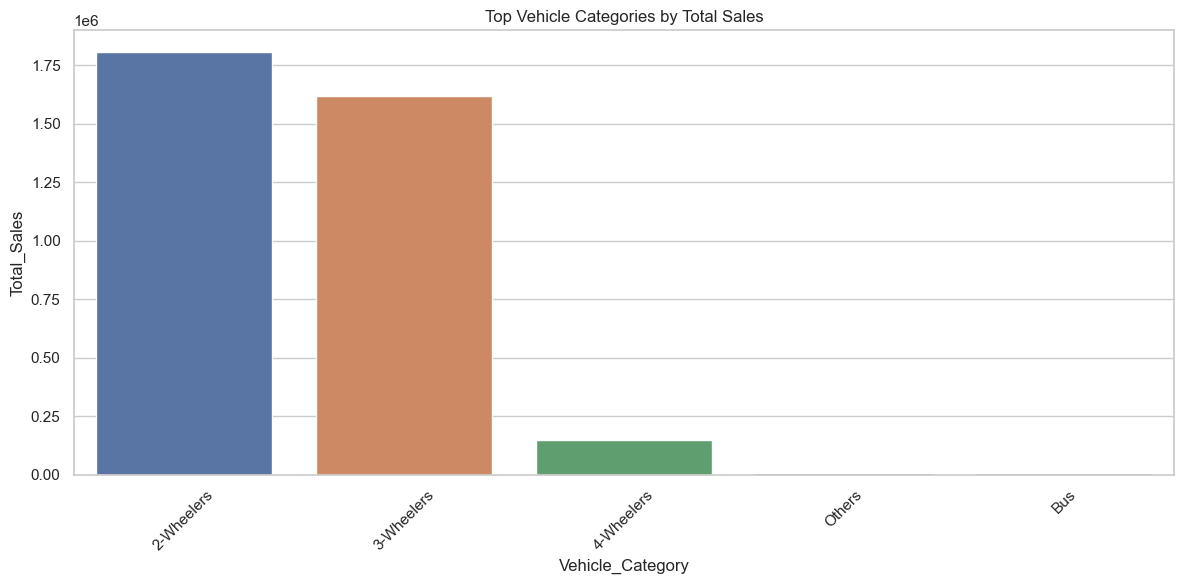

In [21]:
# Plot 1: Top Vehicle Categories by Sales
plt.figure(figsize=(12, 6))
sns.barplot(x='Vehicle_Category', y='Total_Sales', data=category_sales.head(10))
plt.title('Top Vehicle Categories by Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_categories_by_sales.png')

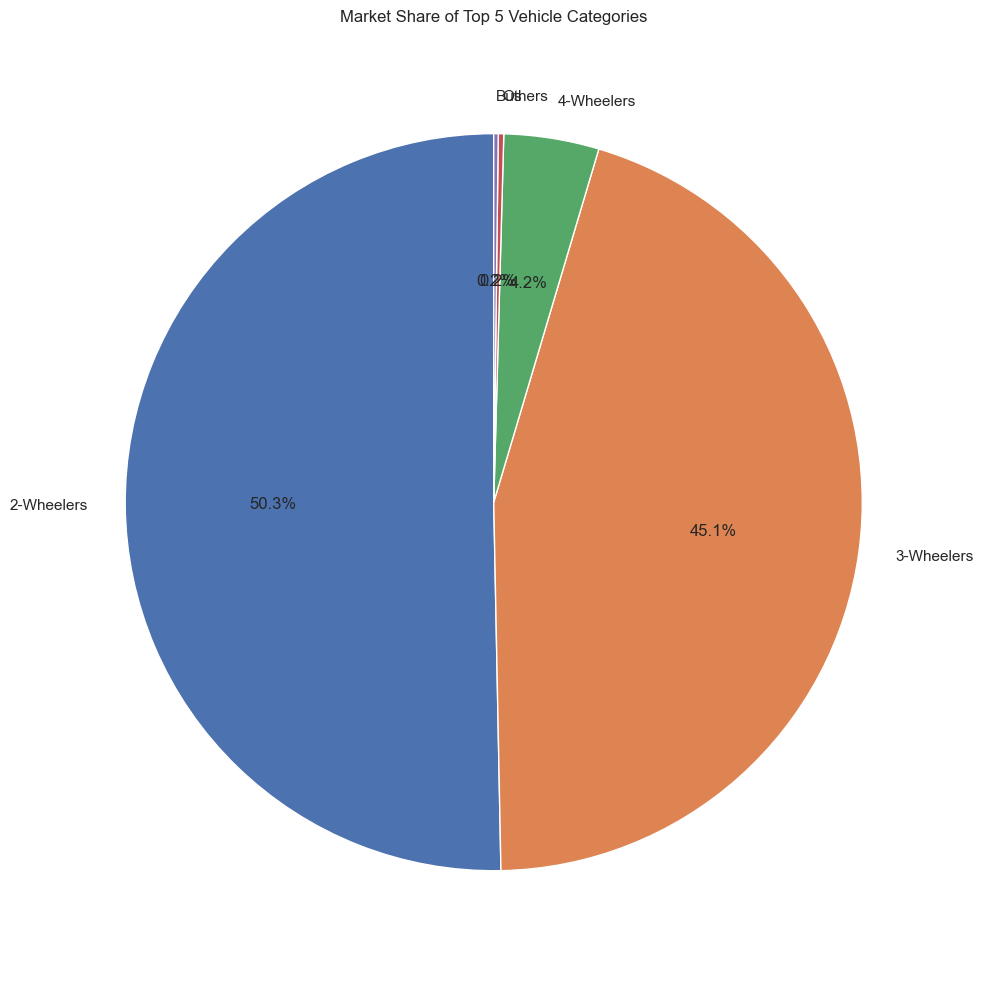

In [22]:
#Plot 2: Market Share by Vehicle Category (Pie Chart)
plt.figure(figsize=(10, 10))
plt.pie(category_sales['Market_Share'].head(5), labels=category_sales['Vehicle_Category'].head(5), 
        autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Market Share of Top 5 Vehicle Categories')
plt.tight_layout()
plt.savefig('market_share_pie_chart.png')

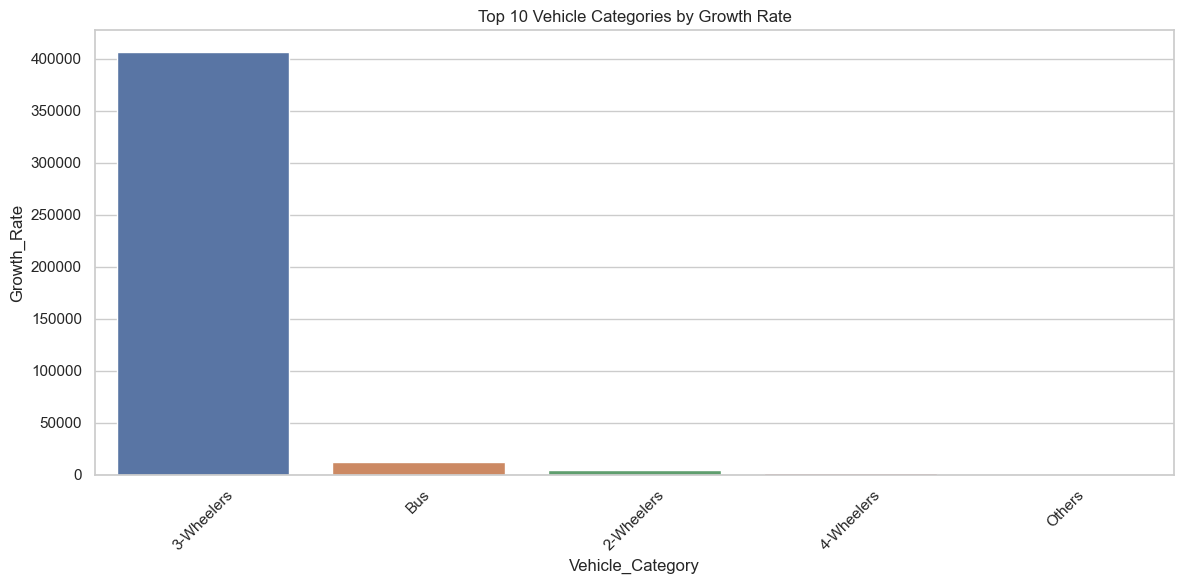

In [23]:
# Plot 3: Growth Rate by Category (if available)
if 'Growth_Rate' in category_sales.columns:
    plt.figure(figsize=(12, 6))
    growth_data = category_sales.sort_values('Growth_Rate', ascending=False).head(10)
    sns.barplot(x='Vehicle_Category', y='Growth_Rate', data=growth_data)
    plt.title('Top 10 Vehicle Categories by Growth Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('category_growth_rates.png')

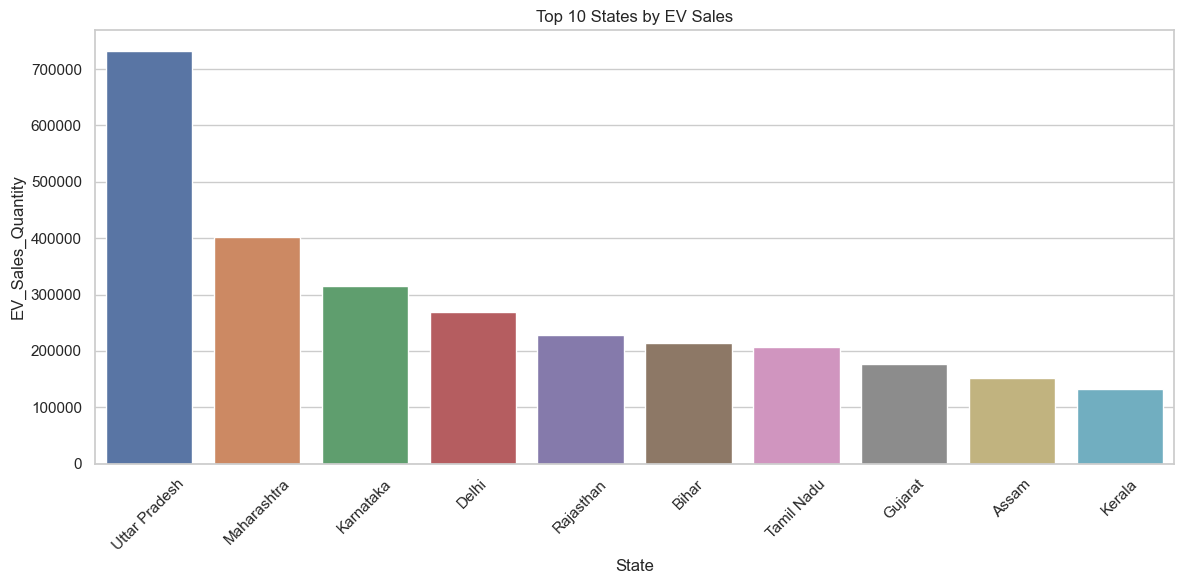

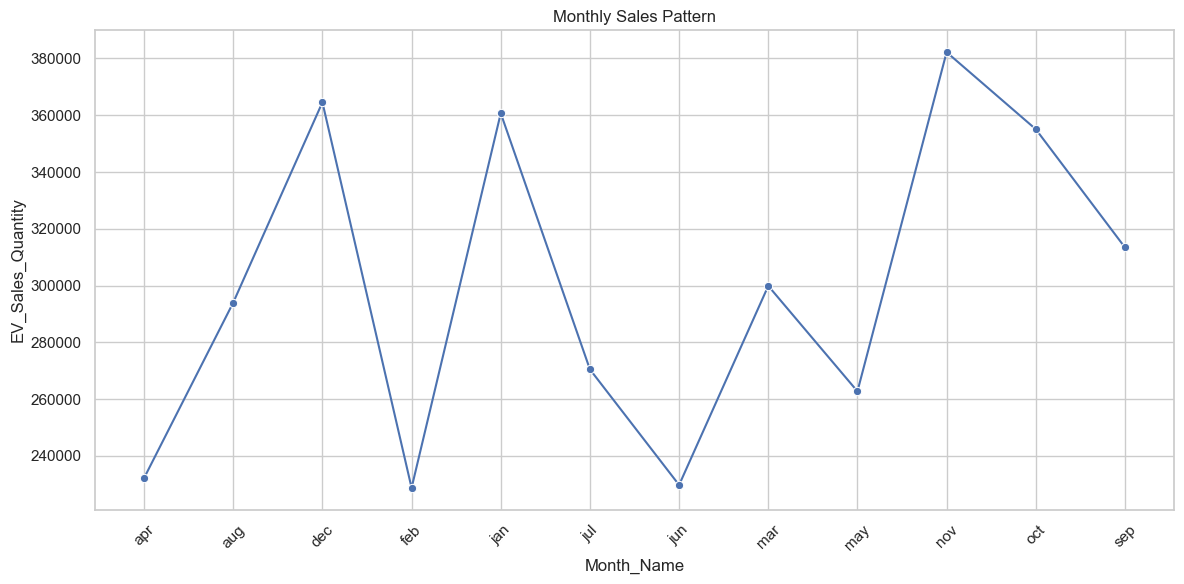

In [24]:
# Plot 4: Geographic Distribution (Top States)
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='EV_Sales_Quantity', data=top_states)
plt.title('Top 10 States by EV Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_states.png')

# Plot 5: Monthly Sales Pattern
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_Name', y='EV_Sales_Quantity', data=monthly_sales, marker='o')
plt.title('Monthly Sales Pattern')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_pattern.png')

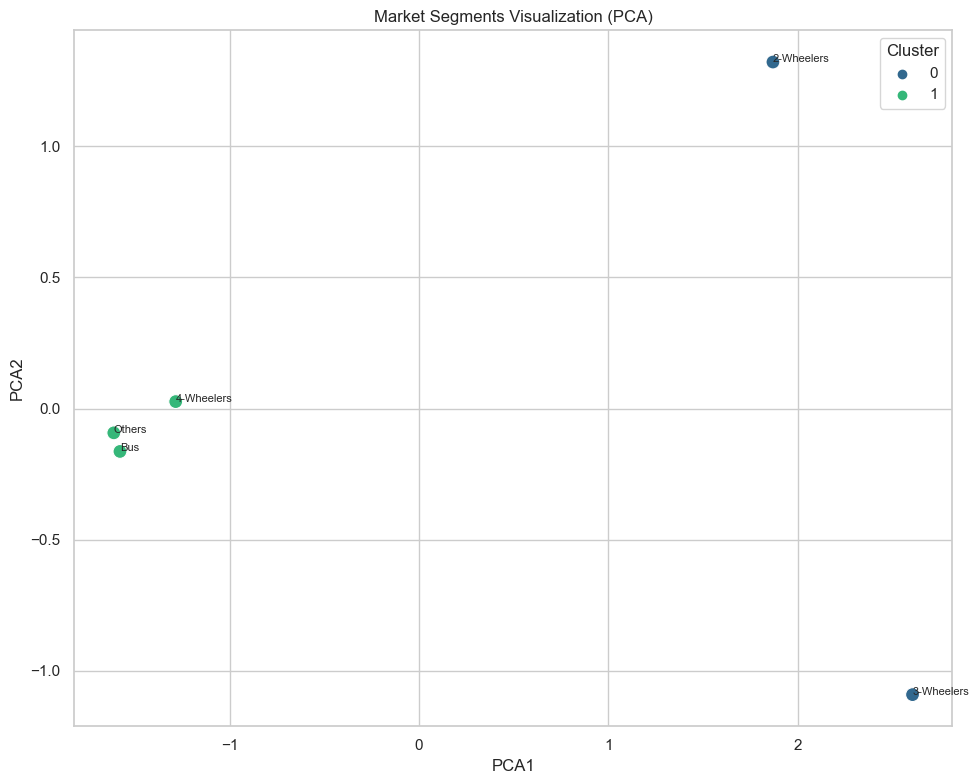

In [25]:
# Plot 6: Cluster Visualization with PCA
if len(scaled_data) > 2:
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    cluster_df = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])
    cluster_df['Cluster'] = category_sales['Cluster']
    cluster_df['Category'] = category_sales['Vehicle_Category']
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=cluster_df, palette='viridis', s=100)
    
    # Add category labels to points
    for i, row in cluster_df.iterrows():
        plt.annotate(row['Category'], (row['PCA1'], row['PCA2']), fontsize=8)
    
    plt.title('Market Segments Visualization (PCA)')
    plt.tight_layout()
    plt.savefig('market_segments_pca.png')

In [66]:
# 7. Recommendations
high_potential_clusters = category_sales.groupby('Cluster')[['Total_Sales', 'Market_Share']].mean().sort_values('Total_Sales', ascending=False)
best_cluster = high_potential_clusters.index[0]
recommended_categories = category_sales[category_sales['Cluster'] == best_cluster].sort_values('Total_Sales', ascending=False)
print(recommended_categories)

  Vehicle_Category  Total_Sales  Average_Sales  Count  Market_Share  \
0       2-Wheelers    1808105.0     137.802378  13121     50.311633   
1       3-Wheelers    1620310.0     141.006875  11491     45.086122   

     Growth_Rate  Cluster  Market_Potential_Score  
0    4741.904762        0                0.604543  
1  407000.000000        0                0.937682  


<font color='blue'> Since the Total_Sales, Count and Market_Share is greater for 2-Wheeler, 2-Wheeler is the best EV to go

In [64]:
print("\nRecommended Vehicle Categories for Market Entry:")
print(recommended_categories[['Vehicle_Category', 'Total_Sales', 'Market_Share']].iloc[0])


Recommended Vehicle Categories for Market Entry:
Vehicle_Category    2-Wheelers
Total_Sales          1808105.0
Market_Share         50.311633
Name: 0, dtype: object


In [54]:
# 8. Top Combinations for Target Marketing
if 'Growth_Rate' in category_sales.columns:
    # Create a score based on both sales and growth
    category_sales['Market_Potential_Score'] = (
        0.6 * (category_sales['Total_Sales'] / category_sales['Total_Sales'].max()) + 
        0.4 * ((category_sales['Growth_Rate'] - category_sales['Growth_Rate'].min()) / 
               (category_sales['Growth_Rate'].max() - category_sales['Growth_Rate'].min() + 0.001))
    )
    
    top_potential = category_sales.sort_values('Market_Potential_Score', ascending=False).head(5)
    print("\nTop 5 Categories by Market Potential Score:")
    print(top_potential[['Vehicle_Category', 'Total_Sales', 'Growth_Rate', 'Market_Potential_Score']])



Top 5 Categories by Market Potential Score:
  Vehicle_Category  Total_Sales    Growth_Rate  Market_Potential_Score
1       3-Wheelers    1620310.0  407000.000000                0.937682
0       2-Wheelers    1808105.0    4741.904762                0.604543
2       4-Wheelers     149775.0    1496.993988                0.051054
4              Bus       7009.0   12575.000000                0.014569
3           Others       8612.0     120.895522                0.002858


In [74]:
#Best state-category combinations
top_states_list = top_states['State'].tolist()
best_combinations = category_state_sales[
    (category_state_sales['Vehicle_Category'].isin(top_potential['Vehicle_Category'])) & 
    (category_state_sales['State'].isin(top_states_list))
].sort_values('EV_Sales_Quantity', ascending=False).head(10)
print("\nBest Category-State Combinations for Target Marketing:")
print(best_combinations)


Best Category-State Combinations for Target Marketing:
   Vehicle_Category          State  EV_Sales_Quantity
64       3-Wheelers  Uttar Pradesh           641906.0
19       2-Wheelers    Maharashtra           342236.0
15       2-Wheelers      Karnataka           278671.0
38       3-Wheelers          Bihar           184394.0
29       2-Wheelers     Tamil Nadu           181735.0
42       3-Wheelers          Delhi           161868.0
10       2-Wheelers        Gujarat           157871.0
37       3-Wheelers          Assam           145575.0
27       2-Wheelers      Rajasthan           137724.0
16       2-Wheelers         Kerala           108118.0


In [72]:
# Display summary
print("\nMARKET ENTRY STRATEGY SUMMARY")
# print(f"1. Primary vehicle categories to focus on: {', '.join(recommended_categories['Vehicle_Category'].tolist()[:3])}")
print(f"1. Top states to target: {', '.join(top_states['State'].tolist()[:5])}")

if 'Growth_Rate' in category_sales.columns:
    fast_growing = category_sales.sort_values('Growth_Rate', ascending=False).head(3)['Vehicle_Category'].tolist()
    print(f"2. Fast-growing categories to watch: {', '.join(fast_growing)}")


MARKET ENTRY STRATEGY SUMMARY
1. Top states to target: Uttar Pradesh, Maharashtra, Karnataka, Delhi, Rajasthan
2. Fast-growing categories to watch: 3-Wheelers, Bus, 2-Wheelers
